In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RSUD Ibu Fatmawati Soekarno Kota Surakarta']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
4174,RSUD Ibu Fatmawati Soekarno Kota Surakarta,4,pak satpam ramah dan respon bagus pelayanan lu...,1,1,"['pelayanan', 'fasilitas']",positive,0.996405,0.990068
4175,RSUD Ibu Fatmawati Soekarno Kota Surakarta,5,pelayanan ramah dan tindakan cepat,1,0,['pelayanan'],positive,0.995815,0.003477
4176,RSUD Ibu Fatmawati Soekarno Kota Surakarta,5,pengalaman rawat inap di rs ini yg pertama ana...,1,1,"['pelayanan', 'fasilitas']",positive,0.994920,0.992186
4177,RSUD Ibu Fatmawati Soekarno Kota Surakarta,5,layanan sangat baik di polikandungan dokter ba...,1,0,['pelayanan'],positive,0.998061,0.006687
4178,RSUD Ibu Fatmawati Soekarno Kota Surakarta,1,saya lahiran disini waktu observasi dikatakan ...,1,0,['pelayanan'],negative,0.996055,0.003823
...,...,...,...,...,...,...,...,...,...
4775,RSUD Ibu Fatmawati Soekarno Kota Surakarta,4,tingkatkan pelayanan dan servis nya mantap,1,0,['pelayanan'],positive,0.996502,0.004148
4776,RSUD Ibu Fatmawati Soekarno Kota Surakarta,2,Adalah baik untuk memiliki layanan untuk ditin...,1,0,['pelayanan'],positive,0.998111,0.007894
4777,RSUD Ibu Fatmawati Soekarno Kota Surakarta,5,bagus,1,1,"['pelayanan', 'fasilitas']",positive,0.997502,0.972857
4778,RSUD Ibu Fatmawati Soekarno Kota Surakarta,5,sehat bersama rsud kota surakarta,1,0,['pelayanan'],neutral,0.912271,0.025746


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

5
2


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,139,-1_pelayanan_pasien_lama_dokter,"[pelayanan, pasien, lama, dokter, sakit, sanga...",[kemarin rumah sakit mengantarkan adik saa...
1,0,277,0_pelayanan_ramah_sangat_baik,"[pelayanan, ramah, sangat, baik, bagus, cepat,...","[pelayanannya sangat baik ramah, pelayanan ba..."
2,1,90,1_jam_sama_pasien_orang,"[jam, sama, pasien, orang, nunggu, mau, bpjs, ...",[periksain anak spesialis kulit pertama hari ...
3,2,45,2_bagus_pelayanan_minus_bgs,"[bagus, pelayanan, minus, bgs, buruk, igd, ram...","[pelayanan buruk, pelayanan satpam minus, min..."
4,3,19,3_mau_dokter_lbh_tolong,"[mau, dokter, lbh, tolong, stpam, blh, nnggu, ...",[antrian polinya ampunpenuh sesaksempithrusnya...


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,32,0_bagus_sehat_buruk_sekali,"[bagus, sehat, buruk, sekali, kelahiran, knp, ...","[bagus, bagus sekali, tetaplah sehat jangan se..."
1,1,179,1_pelayanan_ramah_sangat_ruang,"[pelayanan, ramah, sangat, ruang, bagus, bersi...",[pelayanan ramah ruang truntum perawat cekata...


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             34        4       239
1             77        6         7
2             13        7        25
3             12        5         2

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.122744  0.014440  0.862816
1       0.855556  0.066667  0.077778
2       0.288889  0.155556  0.555556
3       0.631579  0.263158  0.105263

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0              8        3        21
1             47       10       122

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0        0.25000  0.093750  0.656250
1        0.26257  0.055866  0.681564


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

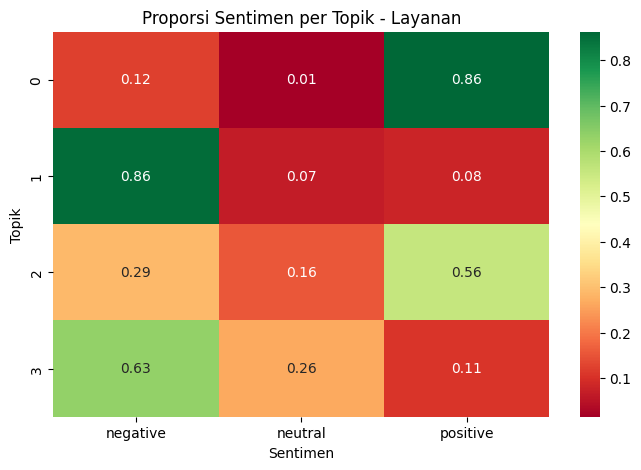

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

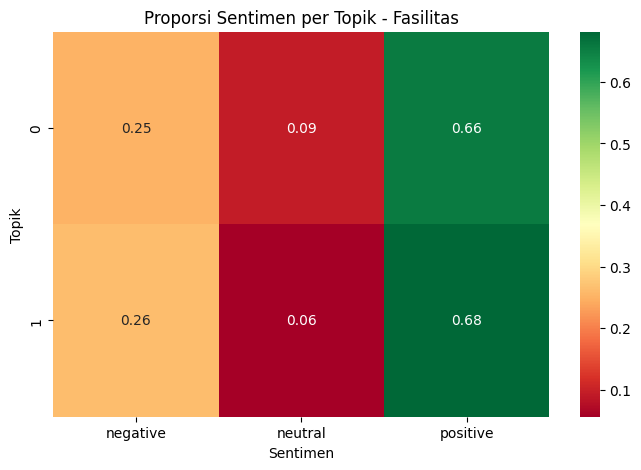

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.04837079362990896)), ('pasien', np.float64(0.044703003405709665)), ('lama', np.float64(0.044507947094773445)), ('dokter', np.float64(0.042662349465079234)), ('sakit', np.float64(0.03253097789575233)), ('sangat', np.float64(0.031955838503299146)), ('bisa', np.float64(0.030936099753714502)), ('rumah', np.float64(0.02969156003102915)), ('jam', np.float64(0.02866626119317593)), ('lebih', np.float64(0.02530545544074718))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.09997388562177155)), ('ramah', np.float64(0.09181348119214844)), ('sangat', np.float64(0.07623896094688985)), ('baik', np.float64(0.06657617717550716)), ('bagus', np.float64(0.055770819391006025)), ('cepat', np.float64(0.04528471620345302)), ('ruang', np.float64(0.04397228948169066)), ('perawat', np.float64(0.042602709257018485)), ('pelayanannya', np.float64(0.03594028518324113)), ('rs

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

2
2


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,28,0_bagus_bgs_sehat_ramah,"[bagus, bgs, sehat, ramah, pakiran, stabil, ba...","[bagus, bagus, Bagus]"
1,1,304,1_pelayanan_ramah_sangat_baik,"[pelayanan, ramah, sangat, baik, bagus, rsud, ...",[sangat puas pelayanan rsud ibu fatmawati so...


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,41,0_pelayanan_buruk_sekali_sangat,"[pelayanan, buruk, sekali, sangat, kurang, lam...",[pelayanan buruk ramah sama sekali staff sa...
1,1,184,1_pasien_jam_pelayanan_dokter,"[pasien, jam, pelayanan, dokter, sama, bisa, m...",[pelayanan poli bedah umum sangat lama dokter...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic 0:
Representasi: [('bagus', np.float64(0.37774423677850155)), ('bgs', np.float64(0.31831154779206217)), ('sehat', np.float64(0.23884979244282387)), ('ramah', np.float64(0.18661187842860139)), ('pakiran', np.float64(0.17455042629998072)), ('stabil', np.float64(0.17455042629998072)), ('bagusss', np.float64(0.17455042629998072)), ('booster', np.float64(0.17455042629998072)), ('moderna', np.float64(0.17455042629998072)), ('sanga', np.float64(0.17455042629998072))]
--------------------------------------------------
Topic 1:
Representasi: [('pelayanan', np.float64(0.1032910674884966)), ('ramah', np.float64(0.08985422214412984)), ('sangat', np.float64(0.07394540992968081)), ('baik', np.float64(0.07097423559916957)), ('bagus', np.float64(0.055896387356536924)), ('rsud', np.float64(0.04387734324746213)), ('ruang', np.float64(0.04276626228708447)), ('cepat', np.float64(0.04107482925459092)), ('perawat', np.float64(0.04050414997374114)), ('dokter', np.fl